# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [2]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element):     
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element):
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [3]:
# ADD AUXILIARY DATA STRUCTURE DEFINITIONS AND HELPER CODE HERE

class multi_key_node:
    
    parent : multi_key_node | None
    keys : list[str]
    children : list[multi_key_node] | None 

    def __init__(self, parent : multi_key_node | None, keys : list[str], children : list[multi_key_node] | None):
        self.parent = parent
        self.keys = keys
        self.children = children

        if self.children:
            for child in self.children:
                if child:
                    child.parent = self

    def insertKey(self, index : int, newKey : str) -> None:
        self.keys.insert(index, newKey)

    def addKey(self, newKey : str) -> None:
        self.keys.append(newKey)
        self.keys.sort()

    def appendChild(self, child : multi_key_node) -> None:
        if not self.children: self.children = []
        self.children.append(child)

    def insertChild(self, index : int, child : multi_key_node) -> None:
        if not self.children : self.children = []
        self.children.insert(index, child)
    
    def childIndex(self) -> int:
        assert self.parent
        return self.parent.children.index(self) if self.parent.children else -1

    def hasChildren(self) -> bool:
        return self.childCount() > 0
    
    def childCount(self) -> int:
        return len(self.children) if self.children else 0
    
    def isTwoNode(self) -> bool:
        return len(self.keys) == 1
    
    def isThreeNode(self) -> bool:
        return len(self.keys) == 2
    
    def isTempFourNode(self) -> bool:
        return len(self.keys) == 3
    
    def getKey(self) -> str:
        assert self.isTwoNode()
        return self.keys[0]
    
    def getLeftKey(self) -> str:
        assert self.isThreeNode() or self.isTempFourNode()
        return self.keys[0]
    
    def getRightKey(self) -> str:
        assert self.isThreeNode() or self.isTempFourNode()
        return self.keys[-1]
    
    def getMidKey(self) -> str:
        assert self.isTempFourNode()
        return self.keys[1]
    
    def getLeft(self) -> multi_key_node | None:
        if self.children and self.childCount() >= 2:
            return self.children[0]
        return None
    
    def getRight(self) -> multi_key_node | None:
        if self.children and self.childCount() >= 2:
            return self.children[-1]
        return None
    
    def getMid(self) -> multi_key_node | None:
        if self.children and self.isThreeNode():
            return self.children[1]
        return None
    
    def getMidLeft(self) -> multi_key_node | None:
        if self.children and self.isTempFourNode():
            return self.children[1]
        return None
    
    def getMidRight(self) -> multi_key_node | None:
        if self.children and self.isTempFourNode():
            return self.children[2]
        return None
    
    def hasKey(self, *keys : str) -> bool:
        for key in keys:
            if key in self.keys:
                return True
        return False

class LLRBBSTNode:
    def __init__(self, element):
        self.element = element
        self.is_red = True
        self.left = None
        self.right = None

Use the cell below to implement the requested API by means of **2-3 Tree** (if among your chosen data structure).

In [ ]:
# made w/ <3 by michael
# might be a little ugly but i like to convince myself its pretty
# ts took me 3 hours to grind... im either stupid or maybe its cus i shower too often

class TwoThreeTree(AbstractSearchInterface):

    def __init__(self, root_key : str | None = None):
        self.root = multi_key_node(parent=None, keys=[root_key], children=None) if root_key else None

    def _splitChildren(self, node : multi_key_node, parent : multi_key_node, index : int) -> multi_key_node:
        assert node.isTempFourNode()

        leftChild = multi_key_node(
            parent = parent,
            keys=[node.getLeftKey()], 
            children = []
        )
        if node.getLeft(): leftChild.appendChild(node.getLeft())  # type: ignore
        if node.getMidLeft(): leftChild.appendChild(node.getMidLeft()) # type: ignore

        rightChild = multi_key_node(
            parent = parent, 
            keys=[node.getRightKey()],
            children = []
        )
        if node.getMidRight(): rightChild.appendChild(node.getMidRight())  # type: ignore
        if node.getRight(): rightChild.appendChild(node.getRight()) # type: ignore

        if parent.children:
            parent.children.pop(index)
        parent.insertChild(index, leftChild)
        parent.insertChild(index + 1, rightChild)
        del node
        return parent
        
    def insertElement(self, element : str):
        # cases
        # case 1 :
        #   insert new key in a 2-node
        #       transform 2-node into a 3-node
        # case 2 :
        #   insert the new key in a 3-node
        #       add new key to a 3-node to make temp 4-node
        #       move middle key of 4-node into its parent node
        #       repeat up the tree as necessary
        #       if you reach the root and it's a 4-node, split into 3 2-nodes
        #          

        if self.root == None:
            self.root = multi_key_node(parent=None, keys=[element], children=None)
            return True

        lastNode : multi_key_node = self._get(element, _returnLastFound = True) # type: ignore
        assert lastNode #should always exist

        if lastNode.hasKey(element):
            return False #already in tree
        
        if lastNode.isTwoNode():
            lastNode.addKey(element)
            return True
        
        lastNode.addKey(element)

        while lastNode and lastNode.isTempFourNode():
            midKey = lastNode.getMidKey()

            if not lastNode.parent: # lastnode is root node
                newRoot = multi_key_node(parent = None, keys=[midKey], children=None)
                leftChild = multi_key_node(parent=newRoot, keys=[lastNode.getLeftKey()], children=[])
                rightChild = multi_key_node(parent=newRoot, keys=[lastNode.getRightKey()], children=[])
                if lastNode.getLeft():
                    leftChild.appendChild(lastNode.getLeft()) # type: ignore
                if lastNode.getMidLeft():
                    leftChild.appendChild(lastNode.getMidLeft()) # type: ignore
                if lastNode.getMidRight():
                    rightChild.appendChild(lastNode.getMidRight()) # type: ignore
                if lastNode.getRight():
                    rightChild.appendChild(lastNode.getRight()) # type: ignore
                newRoot.children = [leftChild, rightChild]
                self.root = newRoot
                break

            parent = lastNode.parent
            childIndex = lastNode.childIndex()
            parent.insertKey(childIndex, midKey)
                            
            self._splitChildren(lastNode, lastNode.parent, childIndex)
            lastNode = lastNode.parent

    
    

    def _get(self, needle : str , node : multi_key_node | None = None, _returnLastFound : bool = False) -> multi_key_node | None:
        # compare search key against those in node
        # find interval containing search key
        # follow associated link (recursively)

        if not node: # initial setup to start search from root
            return self._get(needle, self.root or (None if _returnLastFound else False), _returnLastFound)
        
        if node.hasKey(needle): # check if node is correct
            return node if _returnLastFound else True
        
        if not node.hasChildren(): # check children exist
            return node if _returnLastFound else False

        if node.isTwoNode():
            if needle < node.getKey():
                return self._get(needle, node.getLeft(), _returnLastFound)
            else:
                return self._get(needle, node.getRight(), _returnLastFound)
            
        if node.isThreeNode():            
            leftKey = node.getLeftKey()
            rightKey = node.getRightKey()
            
            if needle < leftKey:
                return self._get(needle, node.getLeft(), _returnLastFound)
            if needle > rightKey:
                return self._get(needle, node.getRight(), _returnLastFound)
            else:
                return self._get(needle, node.getMid(), _returnLastFound)
    
    def searchElement(self, element):     

        
        return self._get(element)

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [14]:
class AVLTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found  

Use the cell below to implement the requested API by means of **LLRB BST** (if among your chosen data structure).

In [ ]:
#courtesy by Ricky

class LLRBBST(AbstractSearchInterface):
    def __init__(self):
        self.root = None

    def _rotate_left(self, n):
        x = n.right
        n.right = x.left
        x.left = n
        x.is_red = n.is_red
        n.is_red = True
        return x

    def _rotate_right(self, n):
        x = n.left
        n.left = x.right
        x.right = n
        x.is_red = n.is_red
        n.is_red = True
        return x

    def _flip_color(self, n):
        n.is_red = True
        n.left.is_red = False
        n.right.is_red = False

    def _put(self, n, element):
        inserted = False

        if n.element == element:
            return n, False
        elif element < n.element:
            if n.left:
                n.left, inserted = self._put(n.left, element)
            else:
                n.left = LLRBBSTNode(element)
                inserted = True
        elif element > n.element:
            if n.right:
                n.right, inserted = self._put(n.right, element)
            else:
                n.right = LLRBBSTNode(element)
                inserted = True

        if n.right and n.right.is_red and (n.left is None or not n.left.is_red):
            n = self._rotate_left(n)
        if n.left and n.left.left and n.left.is_red and n.left.left.is_red:
            n = self._rotate_right(n)
        if n.left and n.right and n.left.is_red and n.right.is_red:
            self._flip_color(n)

        return n, inserted

    def _get(self, n, element):
        if n.element == element:
            return True
        elif element < n.element and n.left:
            return self._get(n.left, element)
        elif element > n.element and n.right:
            return self._get(n.right, element)
        else:
            return False

    def insertElement(self, element):
        if self.root is None:
            self.root = LLRBBSTNode(element)
            return True
        self.root, inserted = self._put(self.root, element)
        return inserted

    def searchElement(self, element):
        if self.root is None:
            return False
        return self._get(self.root, element)

Use the cell below to implement the requested API by means of **B-Tree** (if among your chosen data structure).

In [16]:
class BTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [16]:
# Scapegoat tree by Logan
# A scapegoat tree is a type of self-balancing BST
# Unlike AVl, it does NOT rebalance on every insert
# Rather, is occasionally rebuids the entire subtree

# Essentially, after inserting into a node:
# 1. Check if the tree is "too deep"
# 2. If yes, find an unbalanced ancestor (scapegoat)
# 3. Rebuild that subtree into a perfectly balanced BST

import time
import random
import string

class Node:
    def __init__ (self, key):
        self.key   = key
        self.left  = None
        self.right = None

class ScapegoatTree:
    def __init__ (self, alpha=2/3):
        self.root     = None
        self.n        = 0 # the current number of nodes in the tree
        self.max_size = 0
        self.alpha    = alpha
        # Alpha = 2/3 means that no subtree can be
        # more than ~66% of the tree's total size
        # therefore changing alpha affects performance trade-offs
        # between rebuilding frequency and tree height

    # Standard BST insertion without balancing
    # "path" is used to trace to the root of the subtree (the scapegoat)
    def _insert (self, node, key, path):
        if node is None:
            new_node = Node(key)
            path.append(new_node)
            return new_node
        
        path.append(node)
        
        if key < node.key:
            node.left  = self._insert(node.left, key, path)
        else:
            node.right = self._insert(node.right, key, path)

        return node
    
    # Finds the root / scapegoat node by tracking from bottom to top
    def _find_scapegoat (self, path):
        for i in range (len(path)-1, -1, -1):
            node = path[i]
            left_size  = self._size(node.left)
            right_size = self._size(node.right)
            total_size = 1 + left_size + right_size

            if max(left_size, right_size) > self.alpha * total_size:
                return i
        return None
    
    # Returns the total number of nodes in a subtree
    def _size (self, node):
        if node is None:
            return 0
        return 1 + self._size(node.left) + self._size(node.right)
    
    # Convert a tree into a list in sorted order
    def _in_order (self, node, arr):
        if node is None:
            return
        self._in_order(node.left, arr)
        arr.append(node)
        self._in_order(node.right, arr)

    # Takes a sorted list of nodes and builds a perfectly balanced BST
    def _build_balanced_tree (self, nodes, start, end):
        if start > end:
            return None
        
        mid  = (start+end) // 2
        root = nodes[mid]

        root.left  = self._build_balanced_tree(nodes, start, mid-1)
        root.right = self._build_balanced_tree(nodes, mid+1, end)

        return root
    
    # Rebuild subtree
    def _rebuild (self, node):
        nodes = []
        self._in_order(node, nodes)
        return self._build_balanced_tree(nodes, 0, len(nodes)-1)
    
    # Returns the tree's height
    def _height (self, node):
        if node is None:
            return 0
        return 1 + max(self._height(node.left), self._height(node.right))
    
    # Computes the maximum allowed height depending on alpha
    # Due to library restrictions, logarithms were approximated using iterative multiplication.
    # As a result it may be slightly less accurate
    def _log_alpha (self, n):
        if n <= 1:
            return 0
        
        height = 0
        value  = 1
        base   = 1 / self.alpha

        while value < n:
            value *= base
            height += 1
        
        return height
    
    # Standard BST insert but updates size and checks if the tree is too tall
    # If yes, then it rebuilds the whole tree
    def insertElement(self, element):
        path = []
        self.root = self._insert(self.root, element, path)

        self.n += 1
        self.max_size = max(self.max_size, self.n)
        
        if len(path) > self._log_alpha(self.n):
            scapegoat_index = self._find_scapegoat(path)

            if scapegoat_index is not None:
                scapegoat = path[scapegoat_index]

                # rebuild the subtree
                new_subtree = self._rebuild(scapegoat)

                # attach to its parent node
                if scapegoat_index == 0:
                    self.root = new_subtree
                else:
                    parent = path[scapegoat_index - 1]

                    if parent.left == scapegoat:
                        parent.left = new_subtree
                    else:
                        parent.right = new_subtree

    # Standard BST search
    def searchElement(self, element):
        node = self.root
        while node:
            if element == node.key:
                return True
            elif element < node.key:
                node = node.left
            else:
                node = node.right
        return False

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [ ]:
import string
import random

class TestDataGenerator:
    '''
    A class to represent a synthetic data generator.

    ...

    Methods
    -------
    > generates list with size listLen of random strings with
      random string lengths with a minimum length of strLen
      and maximum length maxStrLen.
      if maxStrLen is not specified then it is equal to strLen
      by default, which generates a fixed length string.

    genRandList(listLen : int, strLen : int, maxStrLen : int = 0) -> list[str]:
    

    > generates a sorted list with size listLen of random strings with
      random string lengths with a minimum length of strLen
      and maximum length maxStrLen.
      if maxStrLen is not specified then it is equal to strLen
      by default, which generates a fixed length string.

    genSortedList(listLen : int, strLen : int, maxStrLen : int = 0) -> list[str]


    > generates a nearly sorted list with size listLen of random strings with
      random string lengths with a minimum length of strLen
      and maximum length maxStrLen.
      with amtSwappedPairs as amount of unsorted pairs.
      If maxStrLen is not specified then it is equal to strLen
      by default, which generates a fixed length string.
      If amtSwappedPairs is not specified, then an error is raised.

    genNearlySortedList(listLen : int, strLen : int, maxStrLen : int = 0, amtSwappedPairs : int = 0) -> list[str]
        
    '''
    @staticmethod
    def _genRandString(strLen : int, charset : str | None = None) -> str:
        assert strLen > 0
        return ''.join(random.choices(string.printable or charset, k=strLen))

    @staticmethod
    def _genRandStringRange(minLen : int, maxLen : int) -> str:
        return TestDataGenerator._genRandString(random.randint(minLen, maxLen))

    @staticmethod
    def genRandList(listLen : int, strLen : int, maxStrLen : int = 0) -> list[str]:
        if maxStrLen == 0: maxStrLen = strLen

        return list(set(TestDataGenerator._genRandStringRange(strLen, maxStrLen) for _ in range(listLen)))

    def genSortedList(listLen : int, strLen : int, maxStrLen : int = 0) -> list[str]:
        
        return sorted(TestDataGenerator.genRandList(listLen, strLen, maxStrLen))

    def genNearlySortedList(listLen : int, strLen : int, maxStrLen : int = 0, amtSwappedPairs : int = 0) -> list[str]:
        assert amtSwappedPairs > 0

        sortedList = TestDataGenerator.genSortedList(listLen, strLen, maxStrLen)

        if not listLen: return sortedList

        for _ in range(amtSwappedPairs):
            firstIndex, secondIndex = random.randint(0, listLen - 1), random.randint(0, listLen - 1)

            sortedList[firstIndex], sortedList[secondIndex] = sortedList[secondIndex], sortedList[firstIndex]

        return sortedList

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

In [181]:
import timeit
import matplotlib.pyplot

class ExperimentalFramework:
    '''
    A class to represent an experimental framework.

    ...

    Attributes
    ----------
    
    > list of number of strings to generate for each type of dataset

    DATASET_SIZES : list[int]


    > the length of strings for the dataset with fixed length strings 

    SET_STRING_LENGTH : int

    
    > the minimum length of strings for the dataset with random length strings

    MIN_STRING_LENGTH : int


    > the maximum length of strings for the dataset with random length strings

    MAX_STRING_LENGTH : int

    
    > the amount of pairs that get swapped in a sorted dataset for the nearly sorted dataset

    AMT_SWAPPED_PAIRS : int

    
    > the amount of repeats per test

    AMT_REPEATS : int


    > the name of the unit of time used

    UNIT_NAME : str


    > the factor for multiplying the unit of time with seconds as 1

    UNIT_FACTOR : float


    > dictionary with dataset names as keys and dictionarys
      with dataset size as keys and actual data as values, as values

    datasets : dict[str, dict[int, list[str]]]
    

    Methods
    -------
    
    [to be defined as part of the coursework]

    '''
            
    #ADD YOUR CODE HERE

    DATASET_SIZES : list[int] = list(range(0,10))

    SET_STRING_LENGTH : int = 10
    MIN_STRING_LENGTH : int = 10
    MAX_STRING_LENGTH : int = 50

    AMT_SWAPPED_PAIRS : int = 5

    AMT_REPEATS       : int = 10

    UNIT_NAME         : str = "secs"
    UNIT_FACTOR       : int = 1

    trees : dict[str, AbstractSearchInterface] = {
        "TWO_THREE_TREE" : TwoThreeTree(),
        "LLRB_TREE" : LLRBBST(),
        "SCAPEGOAT_TREE" : ScapegoatTree()
    }

    
    def genDataset(self, func : function, strLen : int, maxStrLen : int = 0, dataset_sizes : list[int] = [], amtSwappedPairs : int = 0) -> dict[int, list[str]]:
        assert len(dataset_sizes) > 0
        if amtSwappedPairs:
            return {DATASET_SIZE : func(DATASET_SIZE, strLen, maxStrLen, amtSwappedPairs) for DATASET_SIZE in dataset_sizes}
        return {DATASET_SIZE: func(DATASET_SIZE, strLen, maxStrLen) for DATASET_SIZE in dataset_sizes}
    
    def __init__(self):
        self.datasets : dict[str, dict[int, list[str]]] = dict()

        self.datasets["set_random"]          = self.genDataset(TestDataGenerator.genRandList, self.SET_STRING_LENGTH, dataset_sizes=self.DATASET_SIZES)
        self.datasets["set_sorted"]          = self.genDataset(TestDataGenerator.genSortedList, self.SET_STRING_LENGTH, dataset_sizes=self.DATASET_SIZES)
        self.datasets["set_nearly_sorted"]   = self.genDataset(TestDataGenerator.genNearlySortedList, self.SET_STRING_LENGTH, dataset_sizes=self.DATASET_SIZES, amtSwappedPairs=self.AMT_SWAPPED_PAIRS)

        self.datasets["range_random"]        = self.genDataset(TestDataGenerator.genRandList, self.MIN_STRING_LENGTH, self.MAX_STRING_LENGTH, self.DATASET_SIZES)
        self.datasets["range_sorted"]        = self.genDataset(TestDataGenerator.genSortedList, self.MIN_STRING_LENGTH, self.MAX_STRING_LENGTH, self.DATASET_SIZES)
        self.datasets["range_nearly_sorted"] = self.genDataset(TestDataGenerator.genNearlySortedList, self.MIN_STRING_LENGTH, self.MAX_STRING_LENGTH, self.DATASET_SIZES, self.AMT_SWAPPED_PAIRS)

    def getTestData(self, methodFromTree : function, datasets : dict[str, dict[int, list[str]]], trees : dict[str, AbstractSearchInterface]) -> dict[str, dict[str, dict[int, list[float]]]]:
        savedDict : dict[str, dict[str, dict[int, list[int]]]] = dict()
        for treeName, tree in trees.items():
            savedDict[treeName] = dict()
            for datasetName, dataset in datasets.items():
                savedDict[treeName][datasetName] = dict()
                for datasetSize, data in dataset.items():
                    savedDict[treeName][datasetName][datasetSize] = dict()
                    times : list[int] = list()
                    for element in data:
                        times.append(timeit.timeit(lambda : methodFromTree(tree)(element), number = self.AMT_REPEATS) * self.UNIT_FACTOR)

                    savedDict[treeName][datasetName][datasetSize] = times

        return savedDict
    
    
    def getCSVFormattedData(self, methodName : str, datasets : dict[str, dict[str, dict[int, list[float]]]]):
        CSVLines = []
        # print(datasets)
        #"TREE NAME,METHOD NAME,DATASET TYPE,DATASET SIZE,AVERAGE,STD DEV,STR COUNT,REPEAT AMT,FIXED STR LEN,MIN STR LEN,MAX STR LEN"
        for treeName, dataset in datasets.items():
            for datasetName, data in dataset.items():
                for datasetSize, times in data.items():               

                    CSVString = ""

                    total = sum(times)
                    num = len(times)
                    totalsquares = sum(map(lambda x : x**2, times))
                    avg = total/num if num else 0
                    stddev = (((totalsquares/num) - (avg**2)) if num else 0)**0.5
                    
                    minstrlen = min(map(len, self.datasets[datasetName][datasetSize])) if num > 0 else 0
                    maxstrlen = max(map(len, self.datasets[datasetName][datasetSize])) if num > 0 else 0

                    CSVString = f"{treeName},{methodName},{datasetName},{datasetSize},{avg},{stddev},{num},{self.AMT_REPEATS},"
                    CSVString += f"{minstrlen},,\n" if minstrlen == maxstrlen else f",{minstrlen},{maxstrlen}\n"
                    CSVLines.append(CSVString)

        return CSVLines
    
    timeTakenTestsData = {
        "insertElement" : dict(),
        "searchElement" : dict()
    }
    def runTest(self):
        self.timeTakenTestsData["insertElement"] = self.getTestData(
            lambda tree : tree.insertElement, 
            self.datasets,
            self.trees
        )
        self.timeTakenTestsData["searchElement"] = self.getTestData(
            lambda tree : tree.searchElement,
            self.datasets, 
            self.trees
        )        

    def getInsertTimeTaken(self) -> dict[str, dict[str, dict[int, list[float]]]]:
        if self.timeTakenTestsData["insertElement"] == dict(): self.runTest()

        return self.timeTakenTestsData["insertElement"]
    
    def getSearchTimeTaken(self) -> dict[str, dict[str, dict[int, list[float]]]]:
        if self.timeTakenTestsData["searchElement"] == dict(): self.runTest()

        return self.timeTakenTestsData["searchElement"] 

    def exportData(self, filepath : str = "timetakendata.csv"):
        with open(filepath, "w") as savefile:
            savefile.write("TREE NAME,METHOD NAME,DATASET TYPE,DATASET SIZE,AVERAGE,STD DEV,STR COUNT,REPEAT AMT,FIXED STR LEN,MIN STR LEN,MAX STR LEN\n")
            for methodName, dataset in self.timeTakenTestsData.items():
                savefile.writelines(self.getCSVFormattedData(methodName, dataset))

    def plotData(self):
        
        # savedDict[treeName][datasetName][datasetSize] = times
        tree_size_avg_pairs = dict()
        for treeName in self.trees.keys():
            tree_size_avg_pairs[treeName] = list()
            for _, data in self.getInsertTimeTaken()[treeName].items():
                for datasetSize, times in data.items():
                    tree_size_avg_pairs[treeName].append((datasetSize, sum(times)))

        colours = ["r", "g", "b"]
        treeColour = dict()
        for treeName, size_avg_pairs in tree_size_avg_pairs.items():
            size_avg_pairs = sorted(size_avg_pairs)
            if not treeColour.get(treeName, False):
                treeColour[treeName] = colours.pop()
            
            matplotlib.pyplot.plot([size for (size,_) in size_avg_pairs],[avg for (_,avg) in size_avg_pairs], 'o', mec = treeColour[treeName], mfc = treeColour[treeName])

        matplotlib.pyplot.show()

    



Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.

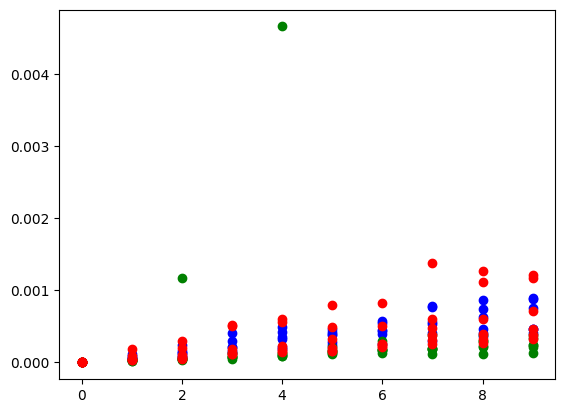

In [182]:
# ADD YOUR TEST CODE HERE 


framework = ExperimentalFramework()

framework.getInsertTimeTaken()

framework.exportData("timetakendata.csv")
framework.plotData()
